Points: 15


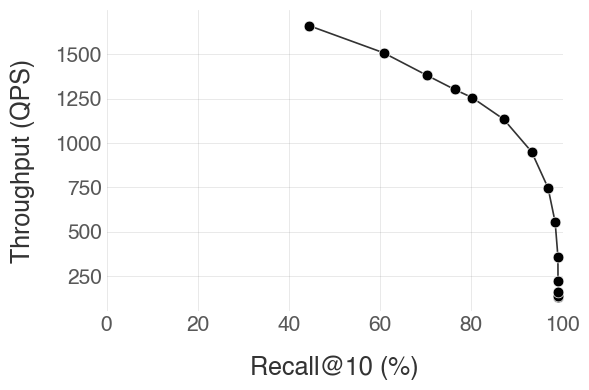

In [10]:
# ---------------------------------------------------------------------------
# Arxiv-only PDXearch (IVF, Row Group, F32) — 14T, black line, no legend
# ---------------------------------------------------------------------------
import json
import pathlib

import matplotlib.pyplot as plt

from common import (
    CASE_NAMES,
    transform_duckdb_index_name,
    apply_style,
    save_fig,
    qps_median_ci,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    MARKER_SIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
)

_TARGET_DATASET = "ArxivForFanns (1.2M × 1024)"
_TARGET_INDEX = "DuckDB PDXearch (IVF, Row Group, F32)"
_TARGET_THREADS = 14

records = []
duckdb_blob_results_dir = pathlib.Path("../experiments/results/index_search_blob/DuckDB")
for path in sorted(duckdb_blob_results_dir.glob("*.json")):
    if path.name.startswith("muted_"):
        continue
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]
        if db_case_cfg.get("index", "") == "FLAT":
            continue
        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)
        index_name = transform_duckdb_index_name(db_case_cfg, global_version)
        dataset = CASE_NAMES.get(case_cfg["case_id"], "")
        threads = db_cfg.get("duckdb_threads", 1)
        if dataset != _TARGET_DATASET or index_name != _TARGET_INDEX or threads != _TARGET_THREADS:
            continue
        latencies = metrics.get("serial_latencies")
        if not latencies:
            continue
        qps, lo, hi = qps_median_ci(latencies)
        records.append((metrics["recall"], qps, lo, hi))

records.sort(key=lambda p: p[0])
print(f"Points: {len(records)}")

apply_style()
fig, ax = plt.subplots(figsize=(6, 4))

recalls = [p[0] for p in records]
qps_vals = [p[1] for p in records]
qps_lo = [p[2] for p in records]
qps_hi = [p[3] for p in records]

ax.errorbar(recalls, qps_vals, yerr=[qps_lo, qps_hi], fmt="none",
            ecolor="black", elinewidth=0.8, capsize=2, capthick=0.8, alpha=0.5, zorder=3)
ax.scatter(recalls, qps_vals, color="black", marker="o", s=MARKER_SIZE,
           zorder=3, edgecolors="white", linewidths=0.5)
ax.plot(recalls, qps_vals, color="black", linewidth=1.2, alpha=0.8, zorder=2)

ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

ax.grid(True, linestyle="-", linewidth=0.6, color="gray", alpha=0.2)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([i / 5 for i in range(6)])
ax.set_xlim(0.0, 1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))

ax.tick_params(axis="both", colors=TICK_FONTS_COLOR, length=0)
ax.tick_params(axis="x", labelsize=TICK_FONTSIZE)
ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

fig.tight_layout()
save_fig("index_search_blob_arxiv_pdxearch")
plt.show()
